# Machine Learning models applied with pipelines.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score, explained_variance_score

import scipy.stats as stats
from scipy.stats import kurtosis, boxcox

import mglearn
import matplotlib

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/Copia de DataBaseSGC.csv', delimiter=';', low_memory=False)
"""df = df.sort_values(by="T_0.01_RotD50", ascending=True)
df.reset_index(drop=True, inplace=True)"""

'df = df.sort_values(by="T_0.01_RotD50", ascending=True)\ndf.reset_index(drop=True, inplace=True)'

In [3]:
df.drop(["Record Sequence Number"], axis=1, inplace=True)
df.drop(["Station ID"], axis=1, inplace=True)
df.drop(["Station Code"], axis=1, inplace=True)
df.drop(["Magnitude type"], axis=1, inplace=True)
df.drop(["EQID"], axis=1, inplace=True)
df.drop(["Valor_T1.5"], axis=1, inplace=True)
df.drop(["Tmax"], axis=1, inplace=True)
df.drop(["Epicenter Latitude (deg; positive N)"], axis=1, inplace=True)
df.drop(["Epicenter Longitude (deg; positive E)"], axis=1, inplace=True)
df.drop(["Station Latitude (deg positive N)"], axis=1, inplace=True)
df.drop(["Station Longitude (deg positive E)"], axis=1, inplace=True)

In [4]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)', 'Style-of-Faulting (S; R; N; U)'], dtype='object')

In [5]:
df = df[df['T_0.01_RotD50'] > 0.001] 
"""df = df[df['Rhypo_OpenQuake'] < 350]
df = df[df['Magnitude'] > 6]

df["T_0.01_RotD50"]= df["T_0.01_RotD50"]/980
df = df[df['T_0.01_RotD50'] > 0.0001]
df["T_0.01_RotD50"]= df["T_0.01_RotD50"]*980"""
df.reset_index(drop=True, inplace=True)

In [6]:
df_copy = df.copy()
X= df_copy.copy()

In [7]:
df_copy["T_0.01_RotD50"]= np.log(df_copy["T_0.01_RotD50"])
#df_copy["Rjb_OpenQuake"]= np.log(df_copy["Rjb_OpenQuake"])

In [8]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),8805.0,60.022135,62.355457,1.000000,10.000000,20.000000,132.000000,209.900000
Magnitude,8805.0,4.988240,0.676097,3.800000,4.500000,4.900000,5.260000,7.782200
Nodal Plane 1 Strike (deg),8805.0,177.691766,106.258851,2.000000,88.000000,168.000000,265.000000,360.000000
Nodal Plane 1 Dip (deg),8805.0,58.318001,23.394911,1.000000,41.000000,65.000000,80.000000,90.000000
Nodal Plane 1 Rake Angle (deg),8805.0,13.536059,109.974724,-180.000000,-69.000000,20.000000,107.000000,180.000000
Nodal Plane 2 Strike (deg),8805.0,169.468938,108.276370,0.000000,71.000000,172.000000,258.000000,360.000000
Nodal Plane 2 Dip (deg),8805.0,68.292334,16.067991,14.000000,58.000000,69.000000,82.000000,90.000000
Nodal Plane 2 Rake Angle (deg),8805.0,18.598637,102.788438,-180.000000,-50.000000,18.000000,100.000000,177.000000
Fault Plane (1; 2; X),8805.0,1.440091,0.496426,1.000000,1.000000,1.000000,2.000000,2.000000
Station Elevation (m),8805.0,1193.155105,1108.177413,4.000000,234.000000,780.000000,1948.000000,4136.000000


In [9]:
Y=X[["T_0.01_RotD50"]].copy()
X.drop(["T_0.01_RotD50"],axis=1, inplace=True)

In [10]:
df_numerico = df_copy.select_dtypes(include=[float, int])

In [11]:
df_copy.drop(["Nodal Plane 1 Rake Angle (deg)"], axis=1, inplace=True)
df_copy.drop(["Nodal Plane 2 Rake Angle (deg)"], axis=1, inplace=True)
df_copy.drop(["Nodal Plane 2 Dip (deg)"], axis=1, inplace=True)
df_copy.drop(["Nodal Plane 2 Strike (deg)"], axis=1, inplace=True)
df_copy.drop(["Rx_OpenQuake"], axis=1, inplace=True)
df_copy.drop(["Ry0_OpenQuake"], axis=1, inplace=True)
df_copy.drop(["Rhypo_OpenQuake"], axis=1, inplace=True)
df_copy.drop(["Rrup_OpenQuake"], axis=1, inplace=True)
df_copy.drop(["Repi_OpenQuake"], axis=1, inplace=True)

In [12]:
# Codificar la variable categórica con OneHotEncoder
X_categorical = df_copy[['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)']].astype(str)

enc = OneHotEncoder(sparse_output=False)
X_encoded = enc.fit_transform(X_categorical)  # Devuelve un array listo para KNN

Y_categorical = df_copy[["Fault Plane (1; 2; X)"]].astype(str)

enc = OneHotEncoder(sparse_output=False)
Y_encoded = enc.fit_transform(Y_categorical)  

Z_categorical = df_copy[["Style-of-Faulting (S; R; N; U)"]].astype(str)

enc = OneHotEncoder(sparse_output=False)
Z_encoded = enc.fit_transform(Z_categorical)  

"""A_categorical = df_copy[['Topografia']].astype(str)

enc = OneHotEncoder(sparse_output=False)
A_encoded = enc.fit_transform(A_categorical)  

B_categorical = df_copy[['Geologia']].astype(str)

enc = OneHotEncoder(sparse_output=False)
B_encoded = enc.fit_transform(B_categorical) """

X_numerical = df_numerico.drop(columns=["T_0.01_RotD50"]).values

# Paso 3: Combinar características numéricas y codificadas
X_final = np.hstack((X_numerical, X_encoded,Y_encoded,Z_encoded#, A_encoded, B_encoded
                     ))

y = df_copy["T_0.01_RotD50"].values  

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.3, random_state=0)

## Pipelines

In [14]:
from sklearn.pipeline import Pipeline


### KNN Neighbors

In [15]:
from sklearn.neighbors import KNeighborsRegressor

In [16]:
pipeKNN = Pipeline([('scaler', MinMaxScaler()),("knn", KNeighborsRegressor(n_neighbors=5))])

In [17]:
param_gridknn = {
    'knn__weights': ['uniform', 'distance'],
    #'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [18]:
grid_searchKNN = GridSearchCV(pipeKNN  , param_grid=param_gridknn, scoring='r2', cv=5, n_jobs=6)
grid_searchKNN.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid_searchKNN.best_score_))
print("Test set score: {:.2f}".format(grid_searchKNN.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchKNN.best_params_))

Best cross-validation accuracy: 0.62
Test set score: 0.64
Best parameters: {'knn__metric': 'manhattan', 'knn__weights': 'uniform'}


In [19]:
pipeKNNnuevo = Pipeline([('scaler', MinMaxScaler()),
                         ("knn", KNeighborsRegressor(n_neighbors=5,
                                                     metric= 'manhattan'))])

In [20]:
pipeKNNnuevo.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('knn', KNeighborsRegressor(metric='manhattan'))])

In [21]:
print("Train score: {:.2f}".format(pipeKNNnuevo.score(X_train, y_train)))
print("Test score: {:.2f}".format(pipeKNNnuevo.score(X_test, y_test)))

Train score: 0.76
Test score: 0.64


In [22]:
y_pred_knn = pipeKNNnuevo.predict(X_test)
y_pred_knn_todos = pipeKNNnuevo.predict(X_final)

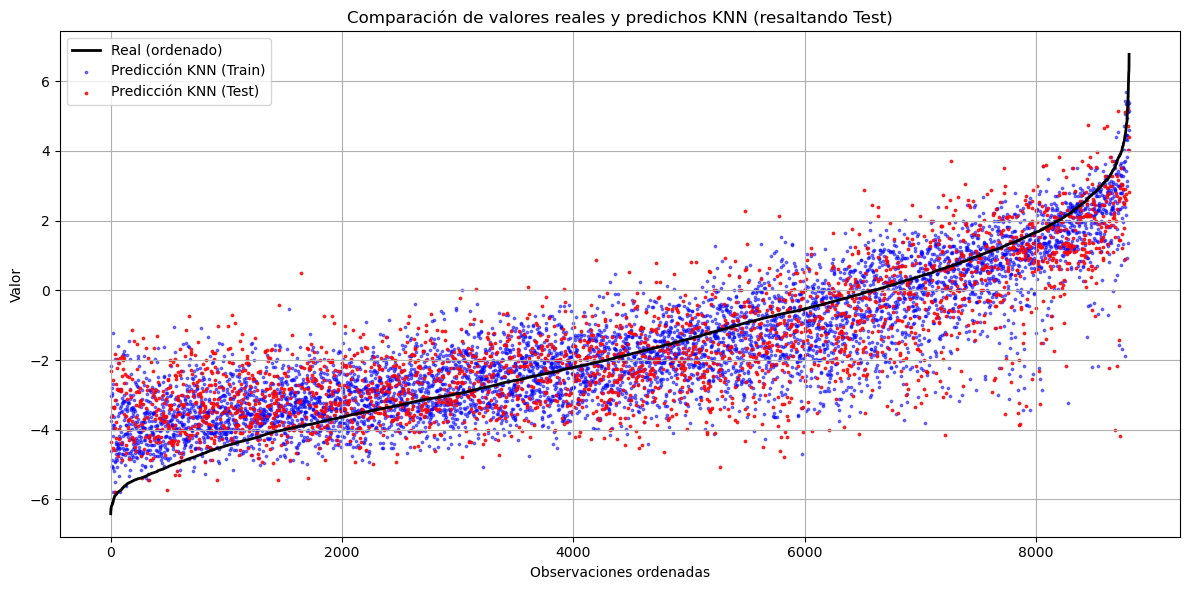

In [23]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_knn_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción KNN (Train)', color='blue', s=3, alpha=0.5)
# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción KNN (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos KNN (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Regresión Lineal

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
pipeLINEAL= Pipeline([('scaler', MinMaxScaler()), ("reglineal", LinearRegression())])

In [26]:
pipeLINEAL.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('reglineal', LinearRegression())])

In [27]:
print("Train score: {:.2f}".format(pipeLINEAL.score(X_train, y_train)))
print("Test score: {:.2f}".format(pipeLINEAL.score(X_test, y_test)))

Train score: 0.53
Test score: 0.54


In [28]:
y_pred_reglineal = pipeLINEAL.predict(X_test)
y_pred_reglineal_todos = pipeLINEAL.predict(X_final)

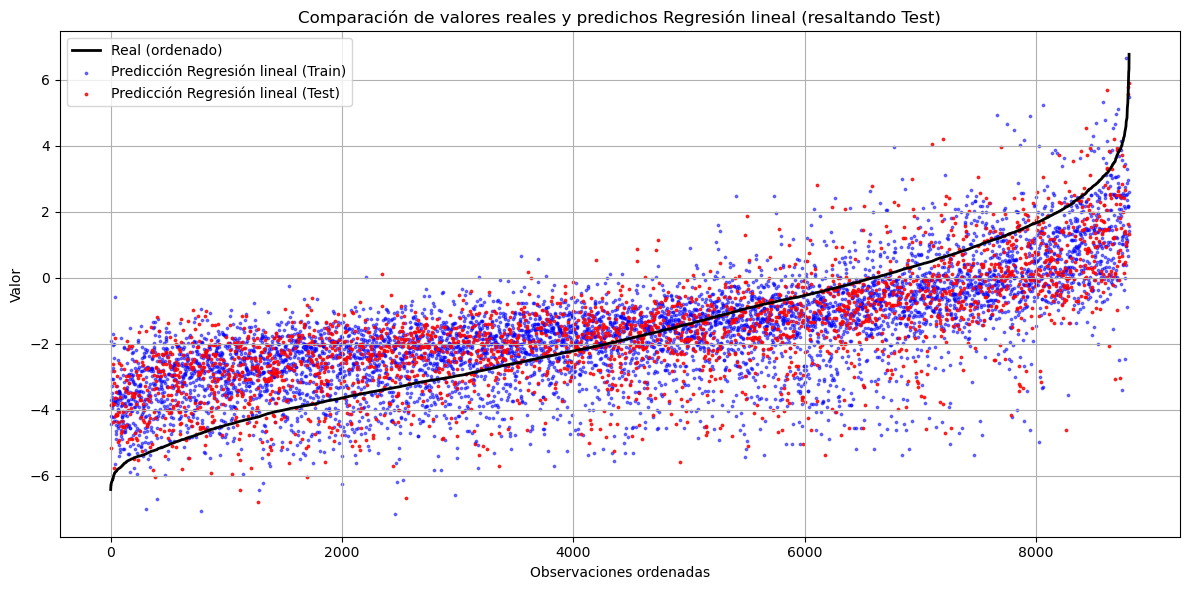

In [29]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_reglineal_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Regresión lineal (Train)', color='blue', s=3, alpha=0.5)
# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Regresión lineal (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos Regresión lineal (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Ridge

In [30]:
from sklearn.linear_model import Ridge

In [31]:
pipeRIDGE= Pipeline([('scaler', MinMaxScaler()), ("ridge", Ridge())])

In [32]:
param_gridridge = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100, 200, 500],  # Regularización
    'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga'],  # Solvers disponibles
    'ridge__tol': [1e-4, 1e-3, 1e-2],  # Tolerancia para la convergencia
    'ridge__max_iter': [1000, 5000, 10000]  # Iteraciones máximas
}

In [33]:
grid_searchRIDGE = GridSearchCV(pipeRIDGE  , param_grid=param_gridridge, scoring='r2', cv=5, n_jobs=6)
grid_searchRIDGE.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid_searchRIDGE.best_score_))
print("Test set score: {:.2f}".format(grid_searchRIDGE.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchRIDGE.best_params_))

Best cross-validation accuracy: 0.53
Test set score: 0.54
Best parameters: {'ridge__alpha': 0.01, 'ridge__max_iter': 1000, 'ridge__solver': 'auto', 'ridge__tol': 0.0001}


In [34]:
pipeRIDGEnuevo = Pipeline([('scaler', MinMaxScaler()),
                         ("ridge", Ridge(alpha= 0.01, max_iter= 1000, solver= 'auto', tol= 0.0001))])

In [35]:
pipeRIDGEnuevo.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('ridge', Ridge(alpha=0.01, max_iter=1000))])

In [36]:
y_pred_Ridge = pipeRIDGEnuevo.predict(X_test)
y_pred_Ridge_todos = pipeRIDGEnuevo.predict(X_final)

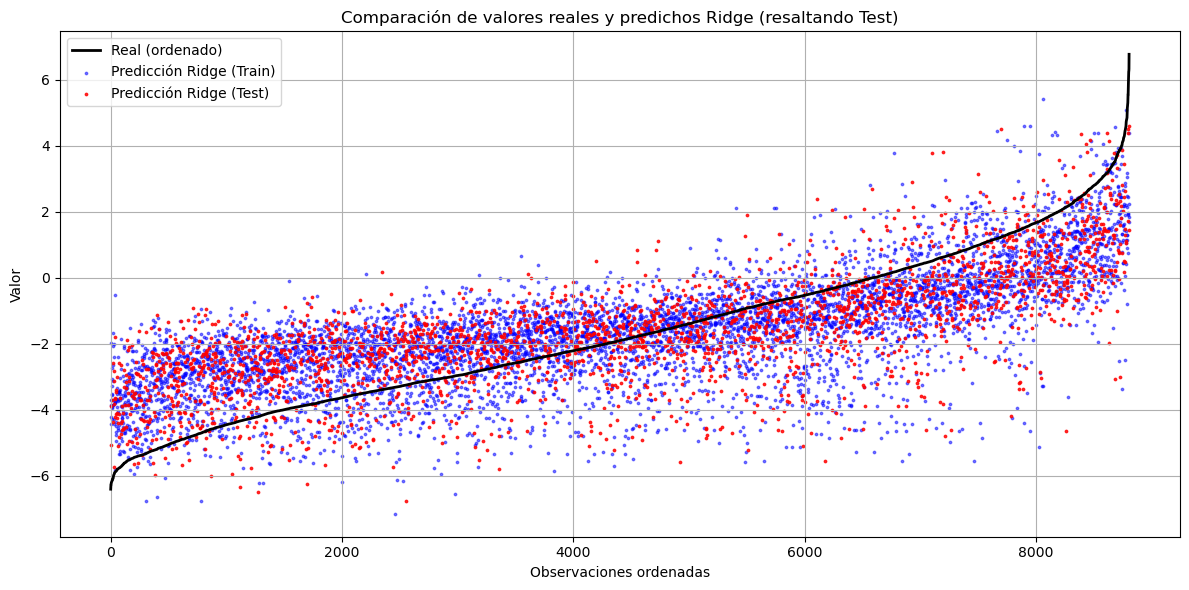

In [37]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_Ridge_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Ridge (Train)', color='blue', s=3, alpha=0.5)
# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Ridge (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos Ridge (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Lasso

In [38]:
from sklearn.linear_model import Lasso

In [39]:
pipeLASSO= Pipeline([('scaler', MinMaxScaler()), ("lasso", Lasso())])

In [40]:
param_gridlasso = {
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],  # Regularización
    'lasso__max_iter': [1000, 5000, 10000],  # Iteraciones máximas para converger
    'lasso__tol': [1e-4, 1e-3, 1e-2]  # Tolerancia de convergencia
}

In [41]:
grid_searchLASSO = GridSearchCV(pipeLASSO  , param_grid=param_gridlasso, scoring='neg_root_mean_squared_error', cv=5, n_jobs=6)
grid_searchLASSO.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid_searchLASSO.best_score_))
print("Test set score: {:.2f}".format(grid_searchLASSO.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchLASSO.best_params_))

Best cross-validation accuracy: -1.58
Test set score: -1.60
Best parameters: {'lasso__alpha': 0.0001, 'lasso__max_iter': 10000, 'lasso__tol': 0.0001}


In [42]:
pipeLASSOnuevo = Pipeline([('scaler', MinMaxScaler()),
                         ("lasso", Lasso(alpha= 0.0001, max_iter=10000, tol= 0.0001))])

In [43]:
pipeLASSOnuevo.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('lasso', Lasso(alpha=0.0001, max_iter=10000))])

In [44]:
y_pred_Lasso = pipeLASSOnuevo.predict(X_test)
y_pred_Lasso_todos = pipeLASSOnuevo.predict(X_final)

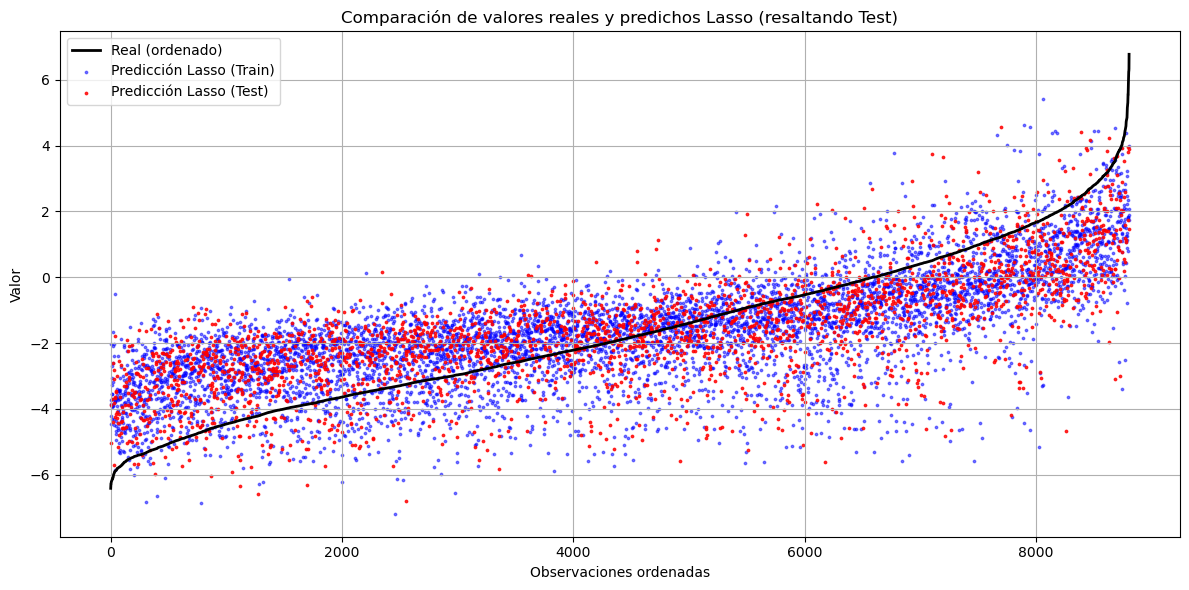

In [45]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_Lasso_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Lasso (Train)', color='blue', s=3, alpha=0.5)
# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Lasso (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos Lasso (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Random Forest

In [46]:
from sklearn.ensemble import RandomForestRegressor

In [47]:
pipeRF= Pipeline([ ("rf", RandomForestRegressor())])

In [48]:
param_gridRF = {
    'rf__n_estimators': [200,300],
    'rf__max_depth': [10,20,30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
}

In [49]:
grid_searchRF = GridSearchCV(pipeRF, param_grid=param_gridRF, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
grid_searchRF.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(-grid_searchRF.best_score_))
print("Test set score: {:.2f}".format(-grid_searchRF.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchRF.best_params_))

Best cross-validation accuracy: 1.02
Test set score: 1.03
Best parameters: {'rf__max_depth': 30, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}


In [50]:
print("Best cross-validation accuracy: 1.09")
print("Test set score: 1.04")
print("Best parameters: {'rf__max_depth': 30, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 300}")

Best cross-validation accuracy: 1.09
Test set score: 1.04
Best parameters: {'rf__max_depth': 30, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 300}


In [51]:
pipeRFnuevo = Pipeline([('rf', RandomForestRegressor(n_estimators=200,max_depth=20,min_samples_split=2,
                                                     criterion='squared_error',min_samples_leaf =2
                                                     , n_jobs=-1))])

In [52]:
pipeRFnuevo.fit(X_train, y_train)

Pipeline(steps=[('rf',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=2,
                                       n_estimators=200, n_jobs=-1))])

In [53]:
print("Train score: {:.2f}".format(pipeRFnuevo.score(X_train, y_train)))
print("Test score: {:.2f}".format(pipeRFnuevo.score(X_test, y_test)))

Train score: 0.96
Test score: 0.81


In [54]:
y_pred_RAND = pipeRFnuevo.predict(X_test)
y_pred_RAND_todos = pipeRFnuevo.predict(X_final)

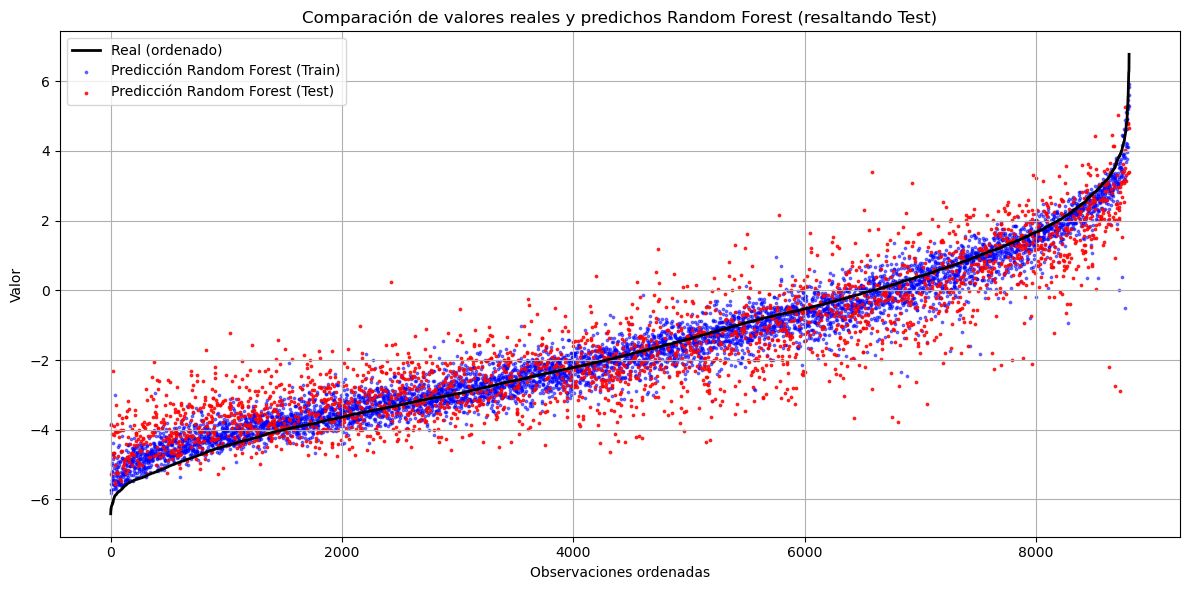

In [55]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_RAND_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Random Forest (Train)', color='blue', s=3, alpha=0.5)
# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Random Forest (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos Random Forest (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### XGBoost

In [56]:
import xgboost as xgb
from xgboost import XGBRegressor
print(xgb.build_info())
print(xgb.__version__)

{'BUILTIN_PREFETCH_PRESENT': False, 'CUDA_VERSION': [12, 4], 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'THRUST_VERSION': [2, 3, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'C:\\Users\\elias\\AppData\\Roaming\\Python\\Python39\\site-packages\\xgboost\\lib\\xgboost.dll'}
2.1.4


In [57]:
pipeXGB= Pipeline([ ("xgb", XGBRegressor(tree_method="gpu_hist", gpu_id=1))])

In [58]:
param_gridXGB = {
    'xgb__max_depth': [5,6],
    'xgb__min_child_weight': [1, 5,10],
    'xgb__subsample': [0.7, 1],
    'xgb__colsample_bytree': [0.7, 1],
    'xgb__learning_rate': [0.1, 0.2],
    'xgb__n_estimators': [100,200],
    'xgb__reg_lambda': [0,1, 10],
    'xgb__reg_alpha': [0,1 ,10]
}

In [59]:
grid_searchXGB = GridSearchCV(pipeXGB, param_grid=param_gridXGB, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
grid_searchXGB.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(-grid_searchXGB.best_score_))
print("Test set score: {:.2f}".format(-grid_searchXGB.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchXGB.best_params_))

Best cross-validation accuracy: 0.90
Test set score: 0.91
Best parameters: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 6, 'xgb__min_child_weight': 1, 'xgb__n_estimators': 200, 'xgb__reg_alpha': 1, 'xgb__reg_lambda': 1, 'xgb__subsample': 1}


In [60]:
print("Best cross-validation RMSE: 0.98")
print("Test set score: 0.91")
print("Best parameters: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 6, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 200, 'xgb__reg_alpha': 1, 'xgb__reg_lambda': 0, 'xgb__subsample': 1}")


Best cross-validation RMSE: 0.98
Test set score: 0.91
Best parameters: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 6, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 200, 'xgb__reg_alpha': 1, 'xgb__reg_lambda': 0, 'xgb__subsample': 1}


In [61]:
pipeXGBnuevo = Pipeline([('xgb', XGBRegressor(colsample_bytree= 0.7,
                            learning_rate= 0.1,
                            max_depth=6,
                            min_child_weight=5,
                            n_estimators= 200,
                            reg_alpha= 1,
                            reg_lambda= 0,
                            subsample= 1))])

In [62]:
pipeXGBnuevo.fit(X_train, y_train)

Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.7, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None, min_child_weight=5,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=200,
                              n_jobs=None, num_parallel_tree=None,
                              random_state=None, ...))])

In [63]:
print("Train score: {:.2f}".format(pipeXGBnuevo.score(X_train, y_train)))
print("Test score: {:.2f}".format(pipeXGBnuevo.score(X_test, y_test)))

Train score: 0.94
Test score: 0.85


In [64]:
y_pred_XGB = pipeXGBnuevo.predict(X_test)
y_pred_XGB_todos = pipeXGBnuevo.predict(X_final)

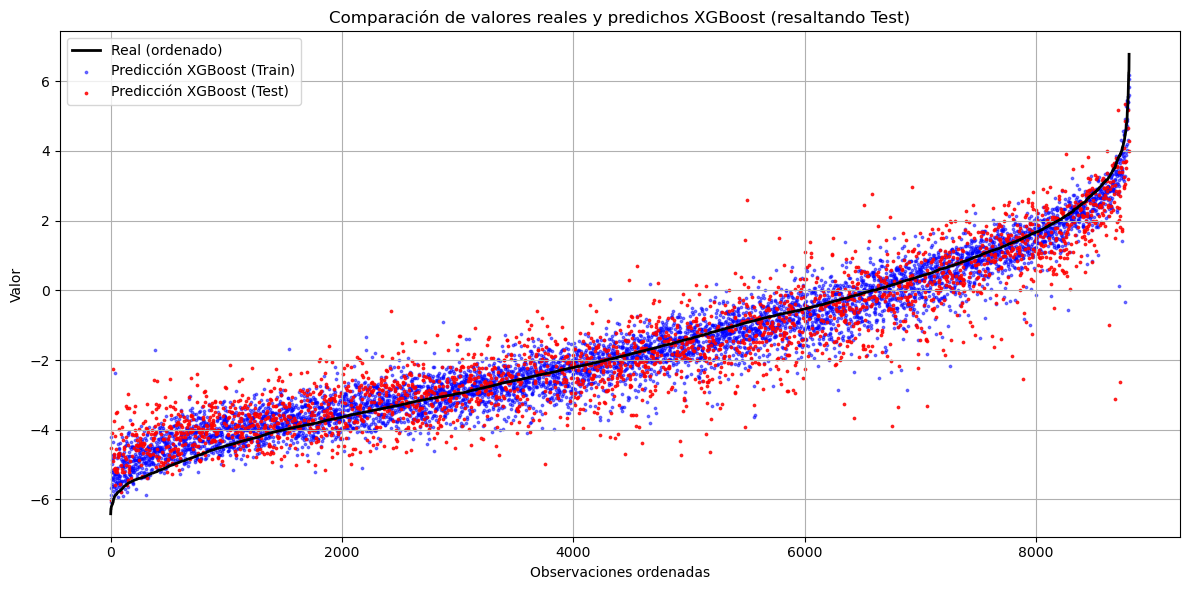

In [65]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_XGB_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción XGBoost (Train)', color='blue', s=3, alpha=0.5)

# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción XGBoost (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos XGBoost (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [66]:
X_XGB=df_copy.copy()

X_XGB[categorical_columns] = X_XGB[categorical_columns].astype('category')

X_XGB.drop(["T_0.01_RotD50"],axis=1, inplace=True)

In [67]:
X_trainXGB, X_testXGB, y_trainXGB, y_testXGB = train_test_split(X_XGB, df_copy["T_0.01_RotD50"], test_size=0.3, random_state=0)
f_importance = XGBRegressor(colsample_bytree= 0.7,learning_rate= 0.1,max_depth=6,min_child_weight=5,n_estimators= 200,reg_alpha= 1,reg_lambda= 0,subsample= 1, enable_categorical=True)
f_importance.fit(X_trainXGB, y_trainXGB)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

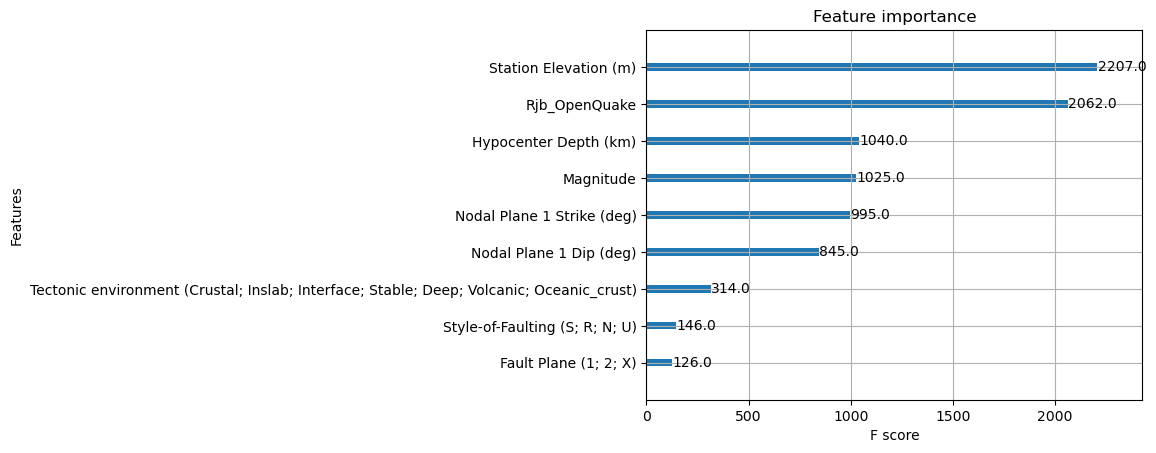

In [68]:
xgb.plot_importance(f_importance)
plt.show()

### SVM

In [69]:
from sklearn.svm import SVR

In [70]:
pipeSVM = Pipeline([("scaler", MinMaxScaler()), ("svm", SVR(kernel ='rbf', shrinking = True))])

In [71]:
param_gridSVM = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100], 
              'svm__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
              'svm__epsilon': [0.001, 0.01, 0.1, 0.5, 1.0],
}

In [72]:
grid_searchSVM = GridSearchCV(pipeSVM, param_grid=param_gridSVM, scoring='neg_root_mean_squared_error', cv=5, n_jobs=6)
grid_searchSVM.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(-grid_searchSVM.best_score_))
print("Test set score: {:.2f}".format(-grid_searchSVM.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchSVM.best_params_))

Best cross-validation accuracy: 1.32
Test set score: 1.35
Best parameters: {'svm__C': 100, 'svm__epsilon': 0.5, 'svm__gamma': 0.1}


In [110]:
pipeSVMnuevo = Pipeline([('scaler', MinMaxScaler()),('svm', SVR(C=100,gamma=0.1,epsilon=0.5 ,kernel='rbf',shrinking=True))])

In [111]:
pipeSVMnuevo.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('svm', SVR(C=100, epsilon=0.5, gamma=0.1))])

In [112]:
print("Train score: {:.2f}".format(pipeSVMnuevo.score(X_train, y_train)))
print("Test score: {:.2f}".format(pipeSVMnuevo.score(X_test, y_test)))

Train score: 0.70
Test score: 0.68


In [113]:
y_pred_SVM = pipeSVMnuevo.predict(X_test)
y_pred_SVM_todos = pipeSVMnuevo.predict(X_final)

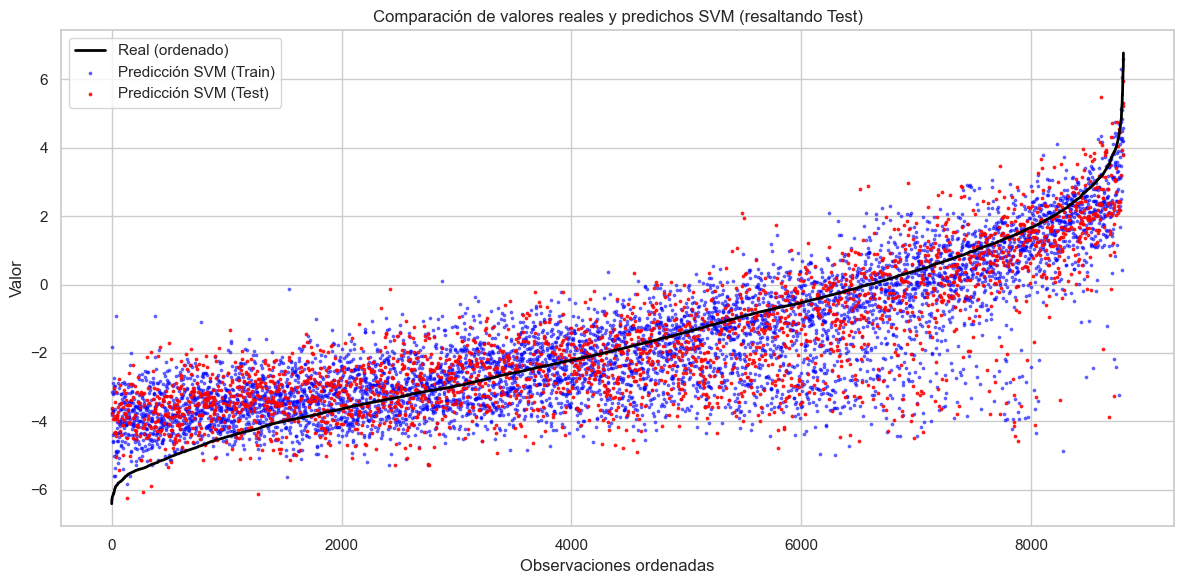

In [114]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_SVM_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción SVM (Train)', color='blue', s=3, alpha=0.5)

# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción SVM (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos SVM (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Meta Stacking

In [115]:
from sklearn.ensemble import StackingRegressor

In [116]:
meta_model = LinearRegression()

In [117]:
stack = StackingRegressor(
    estimators=[],  # por defecto, pero se cambiará con el grid
    final_estimator=meta_model,
    passthrough=False,
    n_jobs=-1
)

In [118]:
param_grid_Stacking = {
    'estimators': [
        [('xgb', pipeXGBnuevo), ('svm', pipeSVMnuevo), ('knn', pipeKNNnuevo), ('rf', pipeRFnuevo) ],
        [('xgb', pipeXGBnuevo), ('svm', pipeSVMnuevo), ('knn', pipeKNNnuevo)],
        [('xgb', pipeXGBnuevo), ('rf', pipeRFnuevo), ('knn', pipeKNNnuevo)],
        [('xgb', pipeXGBnuevo), ('svm', pipeSVMnuevo), ('reg', pipeLINEAL)],
        [('svm', pipeSVMnuevo), ('knn', pipeKNNnuevo), ('reg', pipeLINEAL)],
        [('xgb', pipeXGBnuevo), ('rf', pipeRFnuevo), ('reg', pipeLINEAL)],
        [('svm', pipeSVMnuevo), ('rf', pipeRFnuevo), ('reg', pipeLINEAL)],
        [('xgb', pipeXGBnuevo), ('rf', pipeRFnuevo)],
        [('xgb', pipeXGBnuevo), ('reg', pipeLINEAL)],
        [('svm', pipeSVMnuevo), ('reg', pipeLINEAL)]
    ]}


In [119]:
grid_searchStacking = GridSearchCV(estimator=stack,param_grid=param_grid_Stacking,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)
grid_searchStacking.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=StackingRegressor(estimators=[],
                                         final_estimator=LinearRegression(),
                                         n_jobs=-1),
             n_jobs=-1,
             param_grid={'estimators': [[('xgb',
                                          Pipeline(steps=[('xgb',
                                                           XGBRegressor(base_score=None,
                                                                        booster=None,
                                                                        callbacks=None,
                                                                        colsample_bylevel=None,
                                                                        colsample_bynode=None,
                                                                        colsample_bytree=0.7,
                                                                        device=None,
                                                                        early_stopping_rounds=None,
                                                                        enable_categori...
                                                                        num_parallel_tree=None,
                                                                        random_state=None, ...))])),
                                         ('reg',
                                          Pipeline(steps=[('scaler',
                                                           MinMaxScaler()),
                                                          ('reglineal',
                                                           LinearRegression())]))],
                                        [('svm',
                                          Pipeline(steps=[('scaler',
                                                           MinMaxScaler()),
                                                          ('svm',
                                                           SVR(C=100,
                                                               epsilon=0.5,
                                                               gamma=0.1))])),
                                         ('reg',
                                          Pipeline(steps=[('scaler',
                                                           MinMaxScaler()),
                                                          ('reglineal',
                                                           LinearRegression())]))]]},
             scoring='neg_root_mean_squared_error')

In [120]:
print("Best cross-validation accuracy: {:.2f}".format(-grid_searchStacking.best_score_))
print("Test set score: {:.2f}".format(-grid_searchStacking.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchStacking.best_params_))

Best cross-validation accuracy: 0.90
Test set score: 0.90
Best parameters: {'estimators': [('xgb', Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.7, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None, min_child_weight=5,
                              missing=nan, monotone_constraints=None,
                      

In [121]:
meta_model = LinearRegression()
estimators = [
    ('xgb', pipeXGBnuevo),               
    ('svr', pipeSVMnuevo), 
    ('knn', pipeKNNnuevo),                  
    ('rf', pipeRFnuevo)        
]

In [122]:
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,  # Validación cruzada para entrenar el meta-modelo
    n_jobs=-1,  # Paralelizar si es posible
    passthrough= False
)

In [123]:
stacking_model.fit(X_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('xgb',
                               Pipeline(steps=[('xgb',
                                                XGBRegressor(base_score=None,
                                                             booster=None,
                                                             callbacks=None,
                                                             colsample_bylevel=None,
                                                             colsample_bynode=None,
                                                             colsample_bytree=0.7,
                                                             device=None,
                                                             early_stopping_rounds=None,
                                                             enable_categorical=False,
                                                             eval_metric=None,
                                                             feature_types=None,
                                                             gamma=None,
                                                             grow_policy=None,
                                                             importance_type=None,
                                                             interaction_c...
                              ('svr',
                               Pipeline(steps=[('scaler', MinMaxScaler()),
                                               ('svm',
                                                SVR(C=100, epsilon=0.5,
                                                    gamma=0.1))])),
                              ('knn',
                               Pipeline(steps=[('scaler', MinMaxScaler()),
                                               ('knn',
                                                KNeighborsRegressor(metric='manhattan'))])),
                              ('rf',
                               Pipeline(steps=[('rf',
                                                RandomForestRegressor(max_depth=20,
                                                                      min_samples_leaf=2,
                                                                      n_estimators=200,
                                                                      n_jobs=-1))]))],
                  final_estimator=LinearRegression(), n_jobs=-1)

In [124]:
y_train_pred_stacking = stacking_model.predict(X_train)
y_test_pred_stacking = stacking_model.predict(X_test)
y_pred_stacking_todos = stacking_model.predict(X_final)

In [125]:
print("Train R²:", r2_score(y_train, y_train_pred_stacking))
print("Test R²:", r2_score(y_test, y_test_pred_stacking))

Train R²: 0.9497300238234173
Test R²: 0.8551461912016721


In [126]:
print("Pesos del meta-modelo:", stacking_model.final_estimator_.coef_)

Pesos del meta-modelo: [ 1.00520301 -0.06113729 -0.02655876  0.09847812]


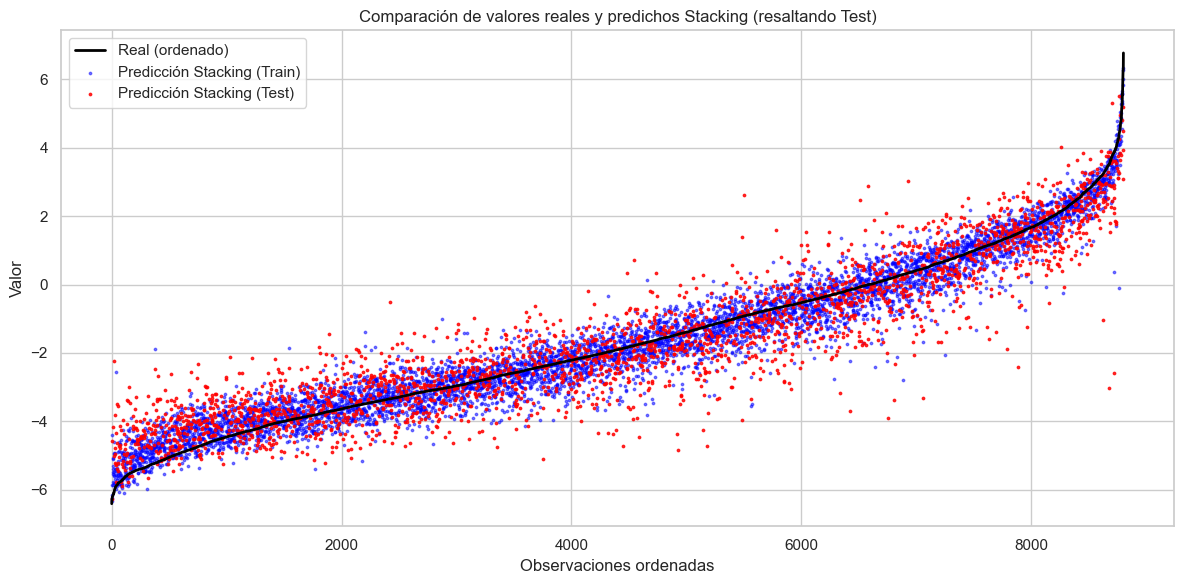

In [127]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_stacking_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Stacking (Train)', color='blue', s=3, alpha=0.5)

# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Stacking (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos Stacking (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

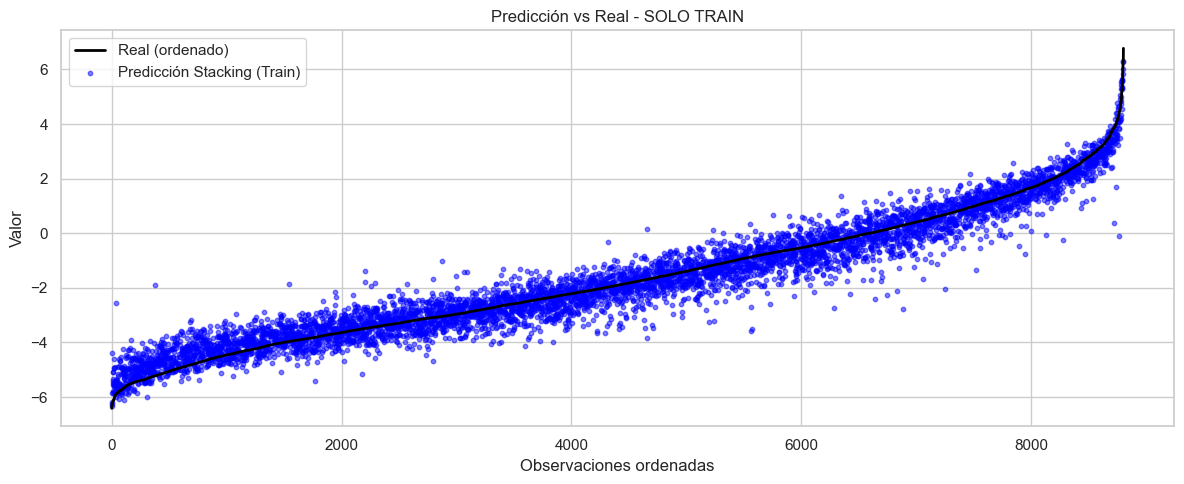

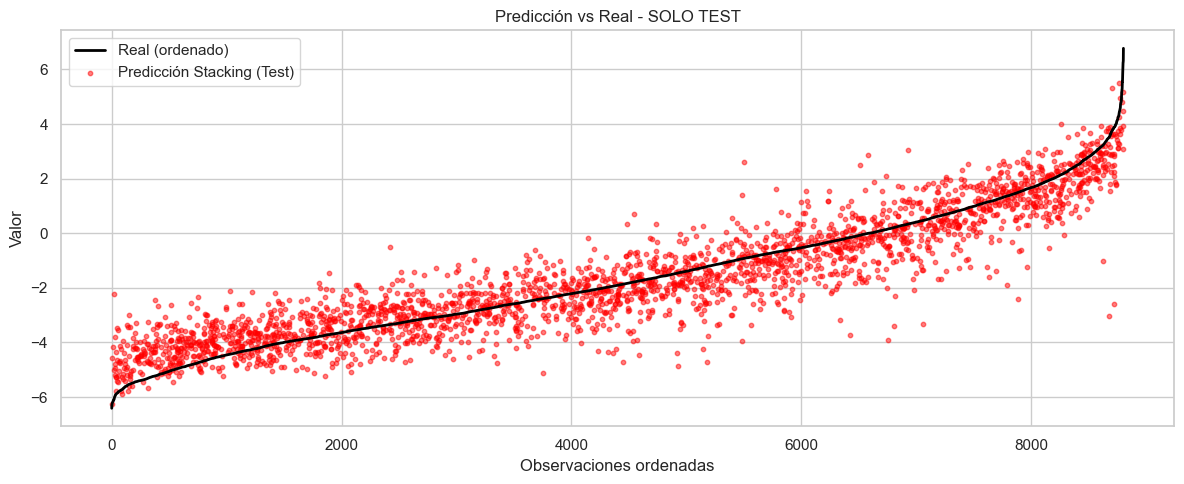

In [128]:
# Ordenar
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_stacking_todos[orden]

# Crear máscara booleana para test
es_test = np.isin(y_real_ordenado, y_test)
# Predicciones sobre Train
plt.figure(figsize=(12, 5))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Stacking (Train)', color='blue', s=10, alpha=0.5)
plt.title('Predicción vs Real - SOLO TRAIN')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Predicciones sobre Test
plt.figure(figsize=(12, 5))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Stacking (Test)', color='red', s=10, alpha=0.5)
plt.title('Predicción vs Real - SOLO TEST')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Tabla de métricas

In [129]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score,mean_absolute_error
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox


epsilon = 1e-6  # Pequeño valor para evitar divisiones por cero

#MAPE

mape_knn = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_knn) * 100
mape_regl = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_reglineal) * 100
mape_ridge = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_Ridge) * 100
mape_lasso = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_Lasso) * 100
mape_rand = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_RAND) * 100
mape_xgb = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_XGB) * 100
mape_svm = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_SVM) * 100
mape_stacking = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_test_pred_stacking) * 100

#MAE

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mae_regl = mean_absolute_error(y_test, y_pred_reglineal)
mae_ridge = mean_absolute_error(y_test, y_pred_Ridge)
mae_lasso = mean_absolute_error(y_test, y_pred_Lasso)
mae_rand = mean_absolute_error(y_test, y_pred_RAND)
mae_xgb = mean_absolute_error(y_test, y_pred_XGB)
mae_svm = mean_absolute_error(y_test, y_pred_SVM)
mae_stacking = mean_absolute_error(y_test, y_test_pred_stacking)

#RMSE

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))  # RMSE
rmse_regl = np.sqrt(mean_squared_error(y_test, y_pred_reglineal))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_Ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_Lasso))
rmse_rand = np.sqrt(mean_squared_error(y_test, y_pred_RAND))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_XGB))
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_SVM))
rmse_stacking = np.sqrt(mean_squared_error(y_test, y_test_pred_stacking))

#R2

r2_knn = r2_score(y_test, y_pred_knn)  # R²
r2_regl = r2_score(y_test, y_pred_reglineal)  # R²
r2_ridge = r2_score(y_test, y_pred_Ridge)  # R²
r2_lasso = r2_score(y_test, y_pred_Lasso)  # R²
r2_rand = r2_score(y_test, y_pred_RAND)  # R²
r2_xgb = r2_score(y_test, y_pred_XGB)
r2_svm = r2_score(y_test, y_pred_SVM)  # R²
r2_stacking = r2_score(y_test, y_test_pred_stacking)  # R²

# Calcular Ljung-Box (test de autocorrelación de residuos)

residuos_knn = y_test - y_pred_knn
ljung_box_knn = acorr_ljungbox(residuos_knn, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_regl = y_test - y_pred_reglineal
ljung_box_regl = acorr_ljungbox(residuos_regl, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_ridge = y_test - y_pred_Ridge
ljung_box_ridge = acorr_ljungbox(residuos_ridge, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_lasso = y_test - y_pred_Lasso
ljung_box_lasso = acorr_ljungbox(residuos_lasso, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_rand = y_test - y_pred_RAND
ljung_box_rand = acorr_ljungbox(residuos_rand, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_xgb = y_test - y_pred_XGB
ljung_box_xgb = acorr_ljungbox(residuos_xgb, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_svm = y_test - y_pred_SVM
ljung_box_svm = acorr_ljungbox(residuos_svm, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_stacking = y_test - y_test_pred_stacking
ljung_box_stacking = acorr_ljungbox(residuos_stacking, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value

# Calcular Jarque-Bera (test de normalidad de residuos)

jb_test_knn = jarque_bera(residuos_knn)
jarque_bera_knn = jb_test_knn.pvalue  # p-value
jb_test_regl = jarque_bera(residuos_regl)
jarque_bera_regl = jb_test_regl.pvalue
jb_test_ridge = jarque_bera(residuos_ridge)
jarque_bera_ridge = jb_test_ridge.pvalue
jb_test_lasso = jarque_bera(residuos_lasso)
jarque_bera_lasso = jb_test_lasso.pvalue
jb_test_rand = jarque_bera(residuos_rand)
jarque_bera_rand = jb_test_rand.pvalue
jb_test_xgb = jarque_bera(residuos_xgb)
jarque_bera_xgb = jb_test_xgb.pvalue
jb_test_svm = jarque_bera(residuos_svm)
jarque_bera_svm = jb_test_svm.pvalue
jb_test_stacking = jarque_bera(residuos_stacking)
jarque_bera_stacking = jb_test_stacking.pvalue


tabla_resultados = pd.DataFrame({
    'Modelo': ['K-NN','Regresión Lineal','Regresión Ridge','Regresión Lasso','Random Forest','XGBoost','SVM','Stacking'],
    'MAE': [mae_knn, mae_regl, mae_ridge, mae_lasso, mae_rand, mae_xgb, mae_svm,mae_stacking],
    'RMSE': [rmse_knn, rmse_regl, rmse_ridge, rmse_lasso, rmse_rand, rmse_xgb, rmse_svm,rmse_stacking],
    'R²': [r2_knn, r2_regl, r2_ridge, r2_lasso, r2_rand, r2_xgb, r2_svm,r2_stacking],
    'Ljung-Box p-value': [ljung_box_knn, ljung_box_regl, ljung_box_ridge, ljung_box_lasso, ljung_box_rand, ljung_box_xgb, ljung_box_svm,ljung_box_stacking],
    'Jarque-Bera p-value': [jarque_bera_knn, jarque_bera_regl, jarque_bera_ridge, jarque_bera_lasso, jarque_bera_rand, jarque_bera_xgb, jarque_bera_svm,jarque_bera_stacking]
})


In [130]:
tabla_resultados

,Modelo,MAE,RMSE,R²,Ljung-Box p-value,Jarque-Bera p-value
0,K-NN,1.097396,1.424008,0.638177,0.864952,1.897277e-47
1,Regresión Lineal,1.274096,1.600522,0.542918,0.801962,1.085169e-17
2,Regresión Ridge,1.276635,1.600778,0.542772,0.869036,3.907231e-17
3,Regresión Lasso,1.277746,1.601887,0.542138,0.881267,5.092686e-17
4,Random Forest,0.799608,1.037215,0.808041,0.764102,1.156261e-83
5,XGBoost,0.681642,0.905405,0.853729,0.887565,5.653030e-253
6,SVM,1.017541,1.346059,0.676705,0.434834,3.489169e-121
7,Stacking,0.675076,0.901010,0.855146,0.763478,1.444107e-259


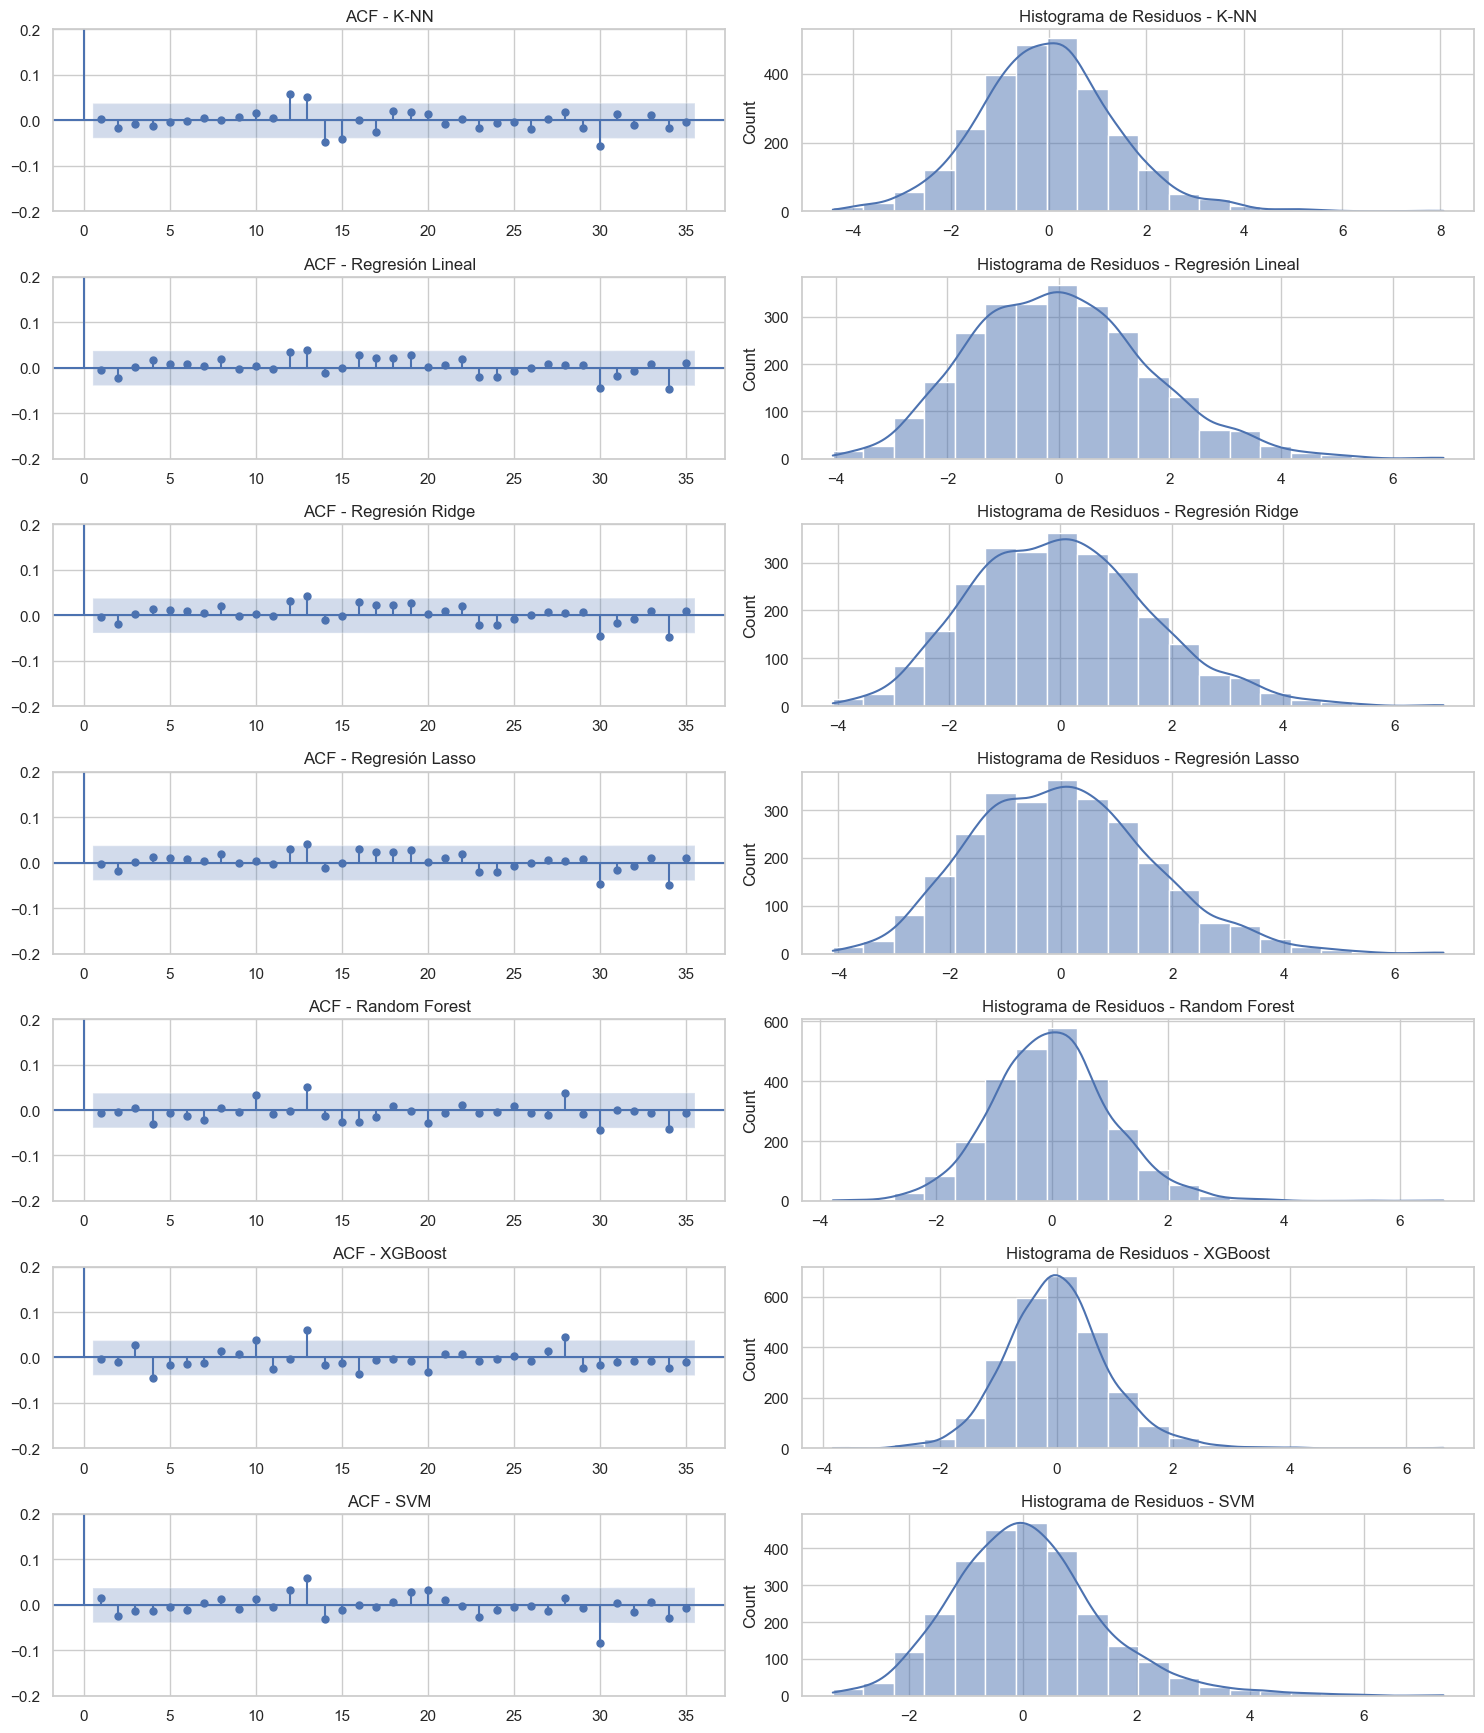

In [131]:
from statsmodels.graphics.tsaplots import plot_acf
modelos = {
    "K-NN": residuos_knn,
    "Regresión Lineal": residuos_regl,
    "Regresión Ridge": residuos_ridge,
    "Regresión Lasso": residuos_lasso,
    "Random Forest": residuos_rand,
    "XGBoost": residuos_xgb,
    "SVM": residuos_svm
}

fig, axes = plt.subplots(len(modelos), 2, figsize=(15, 2.5 * len(modelos)))

for i, (nombre, residuos) in enumerate(modelos.items()):
    # ACF de los residuos
    plot_acf(residuos, ax=axes[i, 0], title=f"ACF - {nombre}")
    axes[i,0].set_ylim(-0.2, 0.2)  # Límite en el eje y
    # Histograma de los residuos
    sns.histplot(residuos, bins=20, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"Histograma de Residuos - {nombre}")
    

plt.tight_layout()
plt.show()

In [133]:
residuos_knn_total = y-y_pred_knn_todos
residuos_regl_total = y-y_pred_reglineal_todos
residuos_ridge_total = y-y_pred_Ridge_todos
residuos_lasso_total = y-y_pred_Lasso_todos
residuos_rand_total = y-y_pred_RAND_todos
residuos_xgb_total = y-y_pred_XGB_todos
residuos_svm_total = y-y_pred_SVM_todos
residuos_stacking_total = y-y_pred_stacking_todos
residuos_total = pd.DataFrame({
    'K-NN': residuos_knn_total,
    'Regresión Lineal': residuos_regl_total,
    'Regresión Ridge': residuos_ridge_total,
    'Regresión Lasso': residuos_lasso_total,
    'Random Forest': residuos_rand_total,
    'XGBoost': residuos_xgb_total,
    'SVM': residuos_svm_total,
    'Stacking': residuos_stacking_total
})

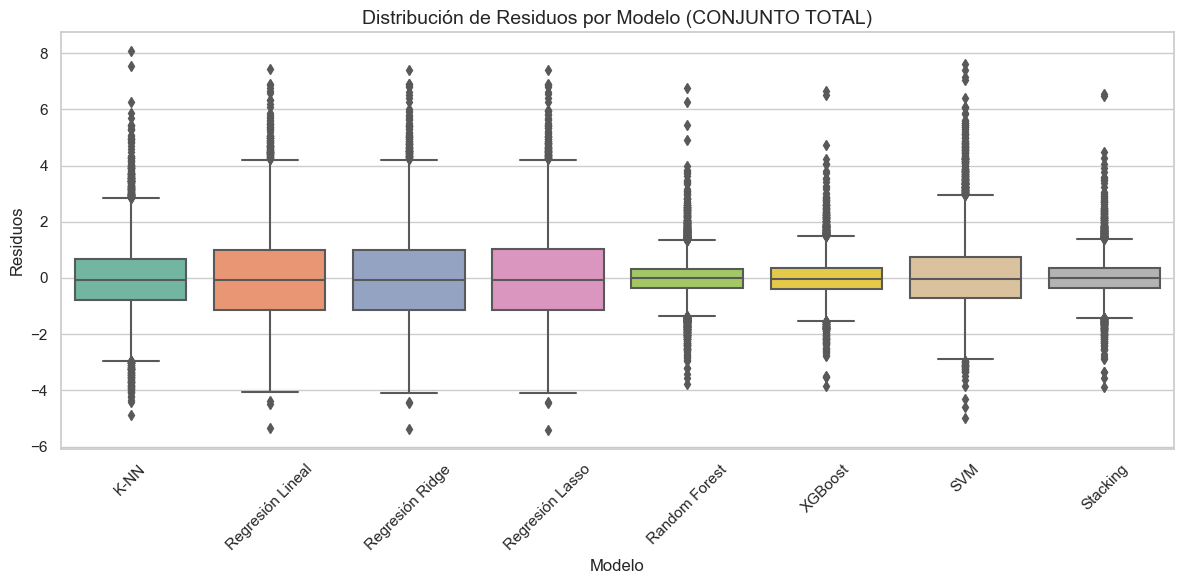

In [134]:
residuos_reales_largo = residuos_total.melt(var_name='Modelo', value_name='Residuos')
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.boxplot(x='Modelo', y='Residuos', data=residuos_reales_largo, palette="Set2")

plt.title('Distribución de Residuos por Modelo (CONJUNTO TOTAL)', fontsize=14)
plt.xlabel('Modelo')
plt.ylabel('Residuos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [135]:
import plotly.express as px

fig = px.box(
    residuos_reales_largo,
    x='Modelo',
    y='Residuos',
    color='Modelo',
    title='Distribución de Residuos por Modelo (CONJUNTO TOTAL)',
    template='plotly_white',
    width=1000,
    height=600
)

fig.update_layout(
    xaxis_title='Modelo',
    yaxis_title='Residuos',
    showlegend=False,
    margin=dict(t=60)
)

fig.show()


In [136]:
residuos_total.describe().T

,count,mean,std,min,25%,50%,75%,max
K-NN,8805.0,-0.024702,1.224457,-4.868551,-0.775286,-0.056825,0.673246,8.062013
Regresión Lineal,8805.0,0.008073,1.582771,-5.319551,-1.130854,-0.082943,1.005881,7.416101
Regresión Ridge,8805.0,0.008237,1.584288,-5.378049,-1.122741,-0.071996,1.010863,7.389235
Regresión Lasso,8805.0,0.008410,1.585925,-5.409216,-1.124169,-0.067929,1.014171,7.388337
Random Forest,8805.0,-0.001874,0.692488,-3.779593,-0.351866,-0.016433,0.323312,6.747373
XGBoost,8805.0,0.003868,0.679614,-3.839861,-0.393510,-0.020978,0.364450,6.637334
SVM,8805.0,0.088868,1.278203,-4.979283,-0.724102,-0.020243,0.744674,7.623925
Stacking,8805.0,0.006397,0.656210,-3.873480,-0.361693,-0.015672,0.343560,6.546695


In [138]:
print(np.exp(3))
print(np.exp(3-2))
print(np.exp(3)-np.exp(2))

20.085536923187668
2.718281828459045
12.696480824257018


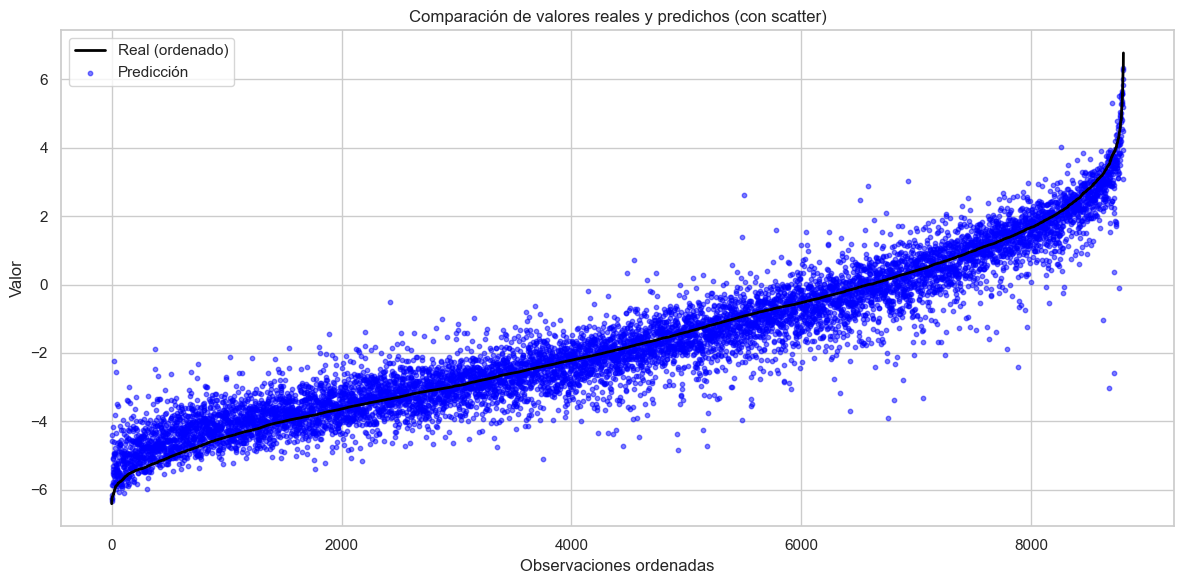

In [ ]:
# 1. Orden
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_stacking_todos[orden]

# 2. Gráfica
plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)
plt.scatter(range(len(y_pred_correspondiente)), y_pred_correspondiente,
            label='Predicción', color='blue', s=10, alpha=0.5)
plt.title('Comparación de valores reales y predichos (con scatter)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import plotly.graph_objects as go
import numpy as np

orden = np.argsort(y)
y_real_orden = y[orden]
y_real_ordenado = np.exp(y_real_orden)
y_pred_correspondiente = np.exp(y_pred_stacking_todos[orden])

# Crear figura interactiva
fig = go.Figure()

# Línea de valores reales ordenados
fig.add_trace(go.Scatter(
    y=y_real_ordenado,
    mode='lines',
    name='Real (ordenado)',
    line=dict(color='black', width=2)
))

# Puntos de predicciones correspondientes
fig.add_trace(go.Scatter(
    y=y_pred_correspondiente,
    mode='markers',
    name='Predicción',
    marker=dict(color='blue', size=4, opacity=0.5)
))

# Configuración del layout
fig.update_layout(
    title='Comparación de valores reales y predichos (interactivo)',
    xaxis_title='Observaciones ordenadas',
    yaxis_title='Valor',
    xaxis=dict(range=[0, 8000]),
    yaxis=dict(range=[0, 25]),
    legend=dict(x=0.01, y=0.99),
    height=600,
    width=1000
)

# Mostrar
fig.show()
